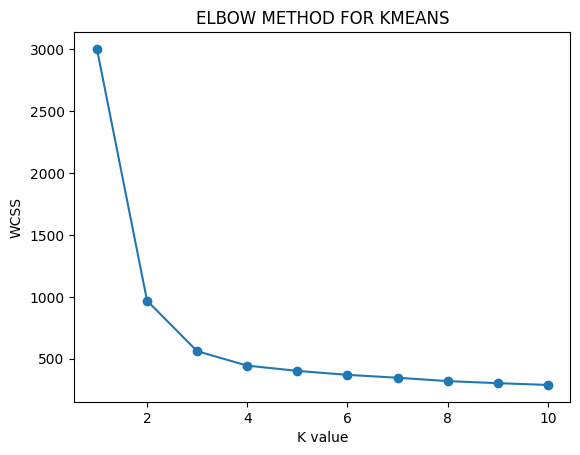

         age  annual_spend  visits_per_month  basket_size  \
0  24.676471  14847.370588         14.341176   558.970588   
1  56.769697  89413.333333          2.527273  5530.545455   
2  40.387879  43340.733333          8.193939  2021.684848   

   days_since_last_visit  num_categories_purchased  
0               9.076471                  2.111765  
1             105.357576                  7.515152  
2              35.187879                  4.424242  
[0.83560354 0.05568764]
          age  annual_spend  visits_per_month  basket_size  \
PC1  0.411569       0.42154         -0.410399     0.412012   
PC2 -0.259432      -0.03327          0.208318    -0.195402   

     days_since_last_visit  num_categories_purchased  
PC1               0.378582                  0.414017  
PC2               0.911194                 -0.140479  


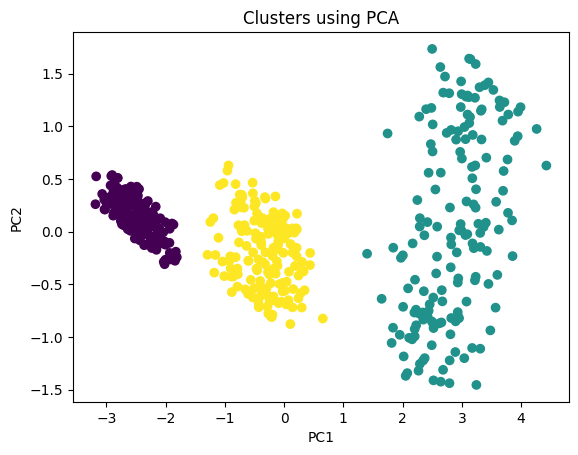

In [ ]:
##======Q2 = UNSUPERVIED LEARNING=======

import pandas as pd

## TASK-1 DATA PREPARATION

from sklearn.preprocessing import StandardScaler

df = pd.read_csv("q2_customers.csv")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

## TASK-2 CHOOSING K--ELBOW METHOD

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss_vals = []

for k in range(1, 11):
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    kmeans_model.fit(X_scaled)
    inertia_val = kmeans_model.inertia_
    wcss_vals.append(inertia_val)

plt.plot(range(1, 11), wcss_vals, marker='o')

plt.xlabel("K value")
plt.ylabel("WCSS")
plt.title("ELBOW METHOD FOR KMEANS")
plt.show()

## TASK-3 K-MEANS CLUSTERING


k_optimal = 3

## FIT K-MEANS
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

## ADING CLUSTER 
df['cluster'] = clusters

centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

##  PRINTING CLUSTER CENTROID
print(centroids)

## PART-4 DIMENSIONALITY REDUCTION WITH PCA

from sklearn.decomposition import PCA

pca_model = PCA(n_components=2)
pca_data = pca_model.fit_transform(X_scaled)

print(pca_model.explained_variance_ratio_)

loadings_df = pd.DataFrame(
    pca_model.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

print(loadings_df)

##TASK-5 CLUSTER VISUALISATION

plt.scatter(pca_data[:, 0], pca_data[:, 1], c=df['cluster'])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("CLUSTER USING PCA")

plt.show()

